In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

plt.rcParams.update({
    "pdf.fonttype": 42,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

data1 = np.load("WKB_QCD_data_chinew/qcd_mc.npz")
data2 = np.load("WKB_QCD_data_chinew2/qcd_mc2.npz")

kappas_all = np.concatenate((data1["kappas"], data2["kappas"]), axis=0)
delta_a_eq_all = np.concatenate((data1["delta_a_eq"], data2["delta_a_eq"]), axis=0)
x_eq_all = np.concatenate((data1["x_eq"], data2["x_eq"]), axis=0)
k_J_eq_all = np.concatenate((data1["k_J_eq"], data2["k_J_eq"]), axis=0) *np.pi*2/4.5
k_RH_all = np.concatenate((data1["k_RH"], data2["k_RH"]), axis=0)
Tend_all = np.concatenate((data1["Tend"], data2["Tend"]), axis=0)
MA0_all = np.concatenate((data1["MA0"], data2["MA0"]), axis=0)
R_RH_all = np.concatenate((data1["R_RH"], data2["R_RH"]), axis=0)
k_osc_all = np.concatenate((data1["k_osc"], data2["k_osc"]), axis=0)
k_L_all = np.concatenate((data1["k_L"], data2["k_L"]), axis=0)

kappa_nls = []

for i in range(len(delta_a_eq_all)):
    kps = kappas_all[i]
    dlt = delta_a_eq_all[i]
    kj = k_J_eq_all[i]
    
    cross = np.where((dlt[:-1] < 1.0) & (dlt[1:] > 1.0))[0]
    
    if len(cross) > 0:
        idx = cross[0]
        k1, k2 = kps[idx], kps[idx+1]
        y1, y2 = dlt[idx], dlt[idx+1]
        
        log_k = np.log10(k1) + (np.log10(1.0) - np.log10(y1)) * (np.log10(k2) - np.log10(k1)) / (np.log10(y2) - np.log10(y1))
        k_val = 10**log_k
        
        if k_val < kj:
            kappa_nls.append(k_val)
        else:
            kappa_nls.append(np.nan)
    else:
        kappa_nls.append(np.nan)

kappa_nls = np.array(kappa_nls)

sort_idx = np.argsort(MA0_all)
MA0_s = MA0_all[sort_idx]
Tend_s = Tend_all[sort_idx]
kappas_s = kappas_all[sort_idx]
delta_a_eq_s = delta_a_eq_all[sort_idx]
k_J_eq_s = k_J_eq_all[sort_idx]
x_eq_s = x_eq_all[sort_idx]
k_RH_s = k_RH_all[sort_idx]
R_RH_s = R_RH_all[sort_idx]
k_osc_s = k_osc_all[sort_idx]
k_L_s = k_L_all[sort_idx]
kappa_nls_s = kappa_nls[sort_idx]

kappa_osc_s = k_osc_s / k_RH_s
kappa_L_s = k_L_s / k_RH_s

Teq_ev = 0.79
Teq_gev = Teq_ev * 1e-9
g_star_eq = 3.36
rho_eq = g_star_eq * (np.pi**2 / 30.0) * (Teq_gev**4) * 0.8
M_solar_GeV = 1.115e57

M_mc_solar_s = np.full_like(MA0_s, np.nan)
valid_m = ~np.isnan(kappa_nls_s)

k_nls_phys = kappa_nls_s[valid_m] * k_RH_s[valid_m]
r_nl_s = (x_eq_s[valid_m] * R_RH_s[valid_m] / k_nls_phys) * (np.pi / 2.0)
M_mc_s = (8.0 * np.pi / 3.0) * rho_eq * (r_nl_s**3)
M_mc_solar_s[valid_m] = M_mc_s / M_solar_GeV

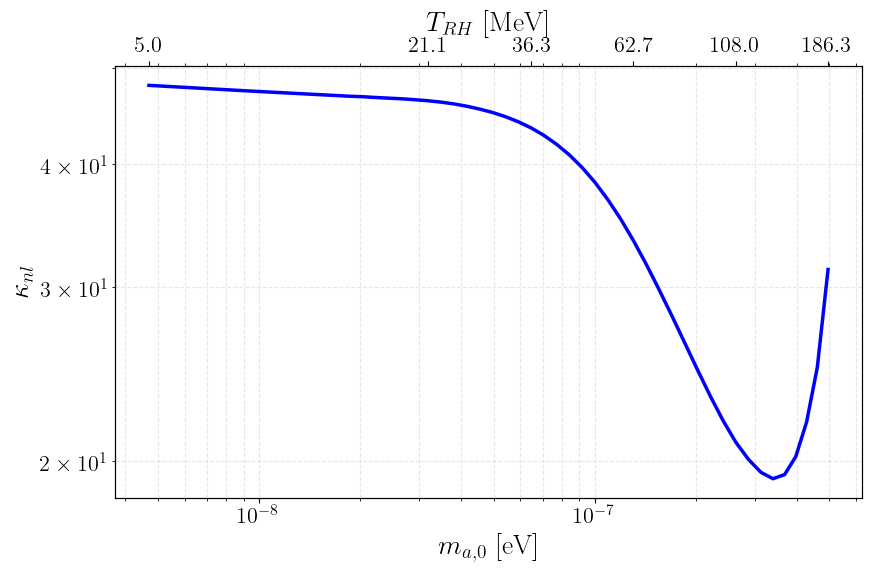

In [2]:
valid = ~np.isnan(kappa_nls_s)
M_v = MA0_s[valid] * 1e9
T_v = Tend_s[valid] * 1e3
K_v = kappa_nls_s[valid]

fig, ax1 = plt.subplots(figsize=(9, 6))

ax1.plot(M_v, K_v, color='blue', lw=2.5)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'$m_{a,0}$ [eV]')
ax1.set_ylabel(r'$\kappa_{nl}$')
ax1.grid(True, which="both", ls="--", alpha=0.3)

ax2 = ax1.twiny()
ax2.set_xscale('log')
ax2.set_xlim(ax1.get_xlim())

n_ticks = 6
idx_ticks = np.linspace(0, len(M_v)-1, n_ticks, dtype=int)
ax2.set_xticks(M_v[idx_ticks])
ax2.set_xticklabels([f"{T_v[i]:.1f}" for i in idx_ticks])
ax2.set_xlabel(r'$T_{RH}$ [MeV]')

plt.tight_layout()
plt.show()

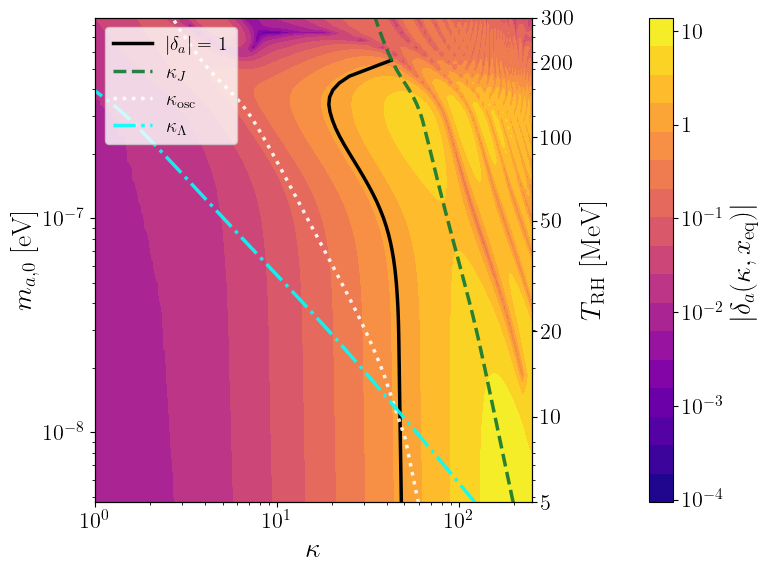

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

X = kappas_s[0]
Y_mass = MA0_s * 1e9
Z = delta_a_eq_s

X_mesh, Y_mesh = np.meshgrid(X, Y_mass)

valid_idx = np.where(~np.isnan(kappa_nls_s))[0]
i1, i2 = valid_idx[-2], valid_idx[-1]

log_m1, log_m2 = np.log10(Y_mass[i1]), np.log10(Y_mass[i2])
log_k1, log_k2 = np.log10(kappa_nls_s[i1]), np.log10(kappa_nls_s[i2])
log_j1, log_j2 = np.log10(k_J_eq_s[i1]), np.log10(k_J_eq_s[i2])

slope_k = (log_k2 - log_k1) / (log_m2 - log_m1)
slope_j = (log_j2 - log_j1) / (log_m2 - log_m1)

log_m_cross = log_m1 + (log_j1 - log_k1) / (slope_k - slope_j)
log_k_cross = log_k1 + slope_k * (log_m_cross - log_m1)

k_plot = np.append(kappa_nls_s[valid_idx], 10**log_k_cross)
m_plot = np.append(Y_mass[valid_idx], 10**log_m_cross)

fig, ax1 = plt.subplots(figsize=(8, 6))

norm = mcolors.LogNorm(vmin=Z.min(), vmax=Z.max())
levels = np.logspace(np.log10(Z.min()), np.log10(Z.max()), 18)

cf = ax1.contourf(X_mesh, Y_mesh, Z, levels=levels, norm=norm, cmap='plasma')

def math_formatter(x, pos):
    if x == 1.0:
        return r'$1$'
    elif x == 10.0:
        return r'$10$'
    else:
        exponent = int(np.floor(np.log10(x)))
        coeff = x / (10**exponent)
        if np.isclose(coeff, 1.0):
            return rf'$10^{{{exponent}}}$'
        else:
            return rf'${coeff:g} \times 10^{{{exponent}}}$'

cbar = fig.colorbar(cf, ax=ax1, pad=0.18)
locator = ticker.LogLocator(base=10.0, numticks=10)
cbar.ax.yaxis.set_major_locator(locator)
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(math_formatter))
cbar.set_label(r'$|\delta_a(\kappa, x_\mathrm{eq})|$')

ax1.plot(k_plot, m_plot, color='black', ls='-', lw=2.5, label=r'$|\delta_a|=1$')
ax1.plot(k_J_eq_s, Y_mass, color='#117733', ls='--', lw=2.5, alpha=0.9, label=r'$\kappa_J$')
ax1.plot(kappa_osc_s, Y_mass, color='white', ls=':', lw=2.5, alpha=0.9, label=r'$\kappa_{\mathrm{osc}}$')
ax1.plot(kappa_L_s, Y_mass, color='#00FFFF', ls='-.', lw=2.5, alpha=0.9, label=r'$\kappa_\Lambda$')

ax1.legend(loc='upper left')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(X.min(), X.max())
ax1.set_xlabel(r'$\kappa$')
ax1.set_ylabel(r'$m_{a,0}$ [eV]')

ax2 = ax1.twinx()
ax2.set_yscale('log')
ax2.set_ylim(ax1.get_ylim()) 

T_mev = Tend_s * 1e3
sort_T_idx = np.argsort(T_mev)
T_sorted = T_mev[sort_T_idx]
Y_sorted = Y_mass[sort_T_idx]

nice_T_ticks = np.array([5, 10, 20, 50, 100, 200, 300])
nice_T_ticks = nice_T_ticks[(nice_T_ticks >= T_sorted[0]) & (nice_T_ticks <= T_sorted[-1])]

log_T_sorted = np.log10(T_sorted)
log_Y_sorted = np.log10(Y_sorted)
log_nice_T = np.log10(nice_T_ticks)

log_tick_positions_Y = np.interp(log_nice_T, log_T_sorted, log_Y_sorted)
tick_positions_Y = 10**log_tick_positions_Y

ax2.set_yticks(tick_positions_Y)
ax2.set_yticklabels([f"{int(t)}" if t == int(t) else f"{t:g}" for t in nice_T_ticks])
ax2.set_ylabel(r'$T_\mathrm{RH}$ [MeV]')

plt.tight_layout()
plt.savefig("delta_a_qcd_eq.pdf", dpi=300)
plt.show()

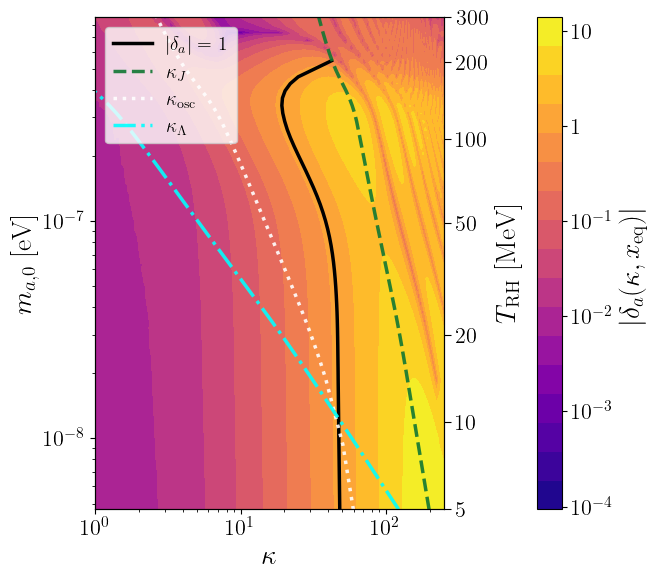

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

kappa_values = np.asarray(kappas_s[0], dtype=float)
axion_mass_values = np.asarray(MA0_s * 1e9, dtype=float)
density_contrast_values = np.asarray(delta_a_eq_s, dtype=float)

kappa_mesh, axion_mass_mesh = np.meshgrid(kappa_values, axion_mass_values)

positive_density_values = density_contrast_values[
    np.isfinite(density_contrast_values)
    & (density_contrast_values > 0.0)
]

density_minimum = positive_density_values.min()
density_maximum = positive_density_values.max()

density_contrast_masked = np.ma.masked_where(
    ~np.isfinite(density_contrast_values)
    | (density_contrast_values <= 0.0),
    density_contrast_values,
)

valid_nonlinear_indices = np.where(
    np.isfinite(kappa_nls_s)
    & np.isfinite(k_J_eq_s)
    & np.isfinite(axion_mass_values)
    & (kappa_nls_s > 0.0)
    & (k_J_eq_s > 0.0)
    & (axion_mass_values > 0.0)
)[0]

last_index = valid_nonlinear_indices[-2]
next_index = valid_nonlinear_indices[-1]

log_mass_last = np.log10(axion_mass_values[last_index])
log_mass_next = np.log10(axion_mass_values[next_index])

log_nonlinear_last = np.log10(kappa_nls_s[last_index])
log_nonlinear_next = np.log10(kappa_nls_s[next_index])

log_jeans_last = np.log10(k_J_eq_s[last_index])
log_jeans_next = np.log10(k_J_eq_s[next_index])

nonlinear_slope = (
    (log_nonlinear_next - log_nonlinear_last)
    / (log_mass_next - log_mass_last)
)

jeans_slope = (
    (log_jeans_next - log_jeans_last)
    / (log_mass_next - log_mass_last)
)

log_crossing_mass = (
    log_mass_last
    + (log_jeans_last - log_nonlinear_last)
    / (nonlinear_slope - jeans_slope)
)

log_crossing_kappa = (
    log_nonlinear_last
    + nonlinear_slope * (log_crossing_mass - log_mass_last)
)

nonlinear_kappa_plot = np.append(
    kappa_nls_s[valid_nonlinear_indices],
    10.0**log_crossing_kappa,
)

nonlinear_mass_plot = np.append(
    axion_mass_values[valid_nonlinear_indices],
    10.0**log_crossing_mass,
)

figure, main_axis = plt.subplots(figsize=(8, 6))

density_norm = mcolors.LogNorm(
    vmin=density_minimum,
    vmax=density_maximum,
)

density_levels = np.logspace(
    np.log10(density_minimum),
    np.log10(density_maximum),
    18,
)

contour_plot = main_axis.contourf(
    kappa_mesh,
    axion_mass_mesh,
    density_contrast_masked,
    levels=density_levels,
    norm=density_norm,
    cmap="plasma",
)

def logarithmic_formatter(value, position):
    if value <= 0.0 or not np.isfinite(value):
        return ""

    if np.isclose(value, 1.0):
        return r"$1$"

    if np.isclose(value, 10.0):
        return r"$10$"

    exponent = int(np.floor(np.log10(value)))
    coefficient = value / 10.0**exponent

    if np.isclose(coefficient, 1.0):
        return rf"$10^{{{exponent}}}$"

    return rf"${coefficient:g} \times 10^{{{exponent}}}$"

colorbar = figure.colorbar(
    contour_plot,
    ax=main_axis,
    pad=0.18,
)

colorbar.ax.yaxis.set_major_locator(
    ticker.LogLocator(base=10.0, numticks=10)
)

colorbar.ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(logarithmic_formatter)
)

colorbar.ax.yaxis.set_minor_locator(ticker.NullLocator())
colorbar.ax.yaxis.set_minor_formatter(ticker.NullFormatter())
colorbar.set_label(r"$|\delta_a(\kappa, x_\mathrm{eq})|$")

main_axis.plot(
    nonlinear_kappa_plot,
    nonlinear_mass_plot,
    color="black",
    ls="-",
    lw=2.5,
    label=r"$|\delta_a|=1$",
)

main_axis.plot(
    k_J_eq_s,
    axion_mass_values,
    color="#117733",
    ls="--",
    lw=2.5,
    alpha=0.9,
    label=r"$\kappa_J$",
)

main_axis.plot(
    kappa_osc_s,
    axion_mass_values,
    color="white",
    ls=":",
    lw=2.5,
    alpha=0.9,
    label=r"$\kappa_{\mathrm{osc}}$",
)

main_axis.plot(
    kappa_L_s,
    axion_mass_values,
    color="#00FFFF",
    ls="-.",
    lw=2.5,
    alpha=0.9,
    label=r"$\kappa_\Lambda$",
)

main_axis.set_xscale("log")
main_axis.set_yscale("log")

main_axis.set_xlim(kappa_values.min(), kappa_values.max())
main_axis.set_ylim(axion_mass_values.min(), axion_mass_values.max())

main_axis.set_xlabel(r"$\kappa$")
main_axis.set_ylabel(r"$m_{a,0}$ [eV]")

main_axis.legend(loc="upper left")

temperature_axis = main_axis.twinx()
temperature_axis.set_yscale("log")
temperature_axis.set_ylim(main_axis.get_ylim())

reheating_temperature_values = np.asarray(Tend_s * 1e3, dtype=float)

temperature_sorting = np.argsort(reheating_temperature_values)

temperature_sorted = reheating_temperature_values[temperature_sorting]
mass_sorted = axion_mass_values[temperature_sorting]

axis_valid_values = (
    np.isfinite(temperature_sorted)
    & np.isfinite(mass_sorted)
    & (temperature_sorted > 0.0)
    & (mass_sorted > 0.0)
)

temperature_sorted = temperature_sorted[axis_valid_values]
mass_sorted = mass_sorted[axis_valid_values]

temperature_ticks = np.array([5, 10, 20, 50, 100, 200, 300], dtype=float)

temperature_ticks = temperature_ticks[
    (temperature_ticks >= temperature_sorted.min())
    & (temperature_ticks <= temperature_sorted.max())
]

temperature_tick_positions = 10.0**np.interp(
    np.log10(temperature_ticks),
    np.log10(temperature_sorted),
    np.log10(mass_sorted),
)

temperature_axis.yaxis.set_major_locator(
    ticker.FixedLocator(temperature_tick_positions)
)

temperature_axis.yaxis.set_major_formatter(
    ticker.FixedFormatter([rf"${int(tick)}$" for tick in temperature_ticks])
)

temperature_axis.yaxis.set_minor_locator(ticker.NullLocator())
temperature_axis.yaxis.set_minor_formatter(ticker.NullFormatter())

temperature_axis.tick_params(
    axis="y",
    which="major",
    direction="out",
    length=5,
    pad=4,
)

temperature_axis.tick_params(
    axis="y",
    which="minor",
    length=0,
)

temperature_axis.set_ylabel(r"$T_\mathrm{RH}$ [MeV]")

figure.subplots_adjust(
    left=0.13,
    right=0.78,
    bottom=0.13,
    top=0.95,
)

figure.savefig("delta_a_qcd_eq.pdf", dpi=300)
plt.show()

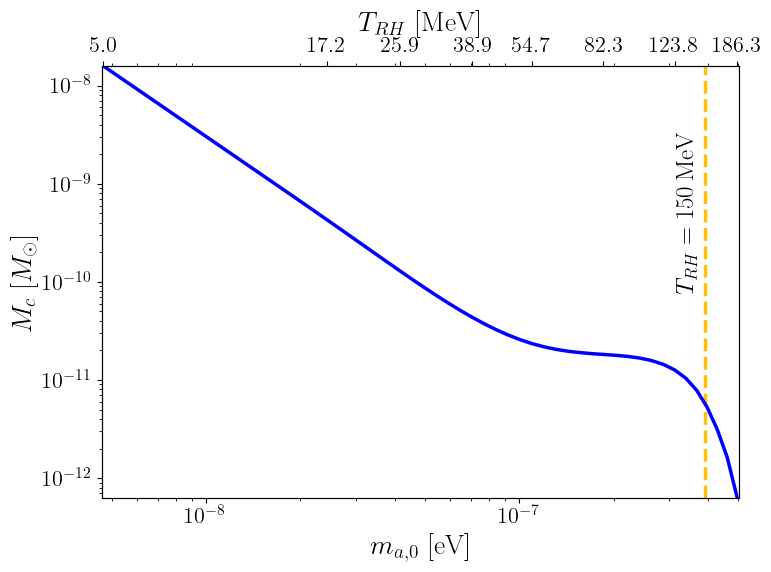

In [4]:
valid = ~np.isnan(M_mc_solar_s)
M_v = MA0_s[valid] * 1e9 
T_v = Tend_s[valid] * 1e3
Mc_v = M_mc_solar_s[valid]

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(M_v, Mc_v, color='blue', lw=2.5)

log_t = np.log10(T_v)
log_m = np.log10(M_v)
sort_t = np.argsort(log_t)
log_m_150 = np.interp(np.log10(150.0), log_t[sort_t], log_m[sort_t])
m_150 = 10**log_m_150

log_m_100 = np.interp(np.log10(100.0), log_t[sort_t], log_m[sort_t])
m_100 = 10**log_m_100

ax1.axvline(m_150, color="#FFC107", ls='--', lw=2.5, zorder=0)

y_mid = 10**((np.log10(Mc_v.max()) + np.log10(Mc_v.min())) / 2.0)
ax1.text(m_150 * 0.95, y_mid*5.0, r'$T_{RH} = 150\,$MeV', color="#000000FF", rotation=90, va='center', ha='right', fontsize=18)


ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(M_v.min() * 0.99, M_v.max() * 1.01)
ax1.set_ylim(Mc_v.min() * 0.99, Mc_v.max() * 1.01)
ax1.set_xlabel(r'$m_{a,0}$ [eV]')
ax1.set_ylabel(r'$M_{c} \ [M_\odot]$')

ax2 = ax1.twiny()
ax2.set_xscale('log')
ax2.set_xlim(ax1.get_xlim())

n_ticks = 8
idx_ticks = np.linspace(0, len(M_v)-1, n_ticks, dtype=int)
ax2.set_xticks(M_v[idx_ticks])
ax2.set_xticklabels([f"{T_v[i]:.1f}" for i in idx_ticks])
ax2.set_xlabel(r'$T_{RH}$ [MeV]')

plt.savefig("QCD_axion_eq.pdf", dpi=300)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from NSC_cosmo import background


plt.rcParams.update({
    "pdf.fonttype": 42,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
})


#Relativistic degrees of freedom for entropy and energy density


data = np.loadtxt("Data/geffcbest.txt", skiprows=0)
T_tab = data[:, 0]
gstar = interp1d(T_tab, data[:, 1], bounds_error=False, fill_value="extrapolate")

data = np.loadtxt("Data/heffcbest.txt", skiprows=0)
T_tab = data[:, 0]
gstars = interp1d(T_tab, data[:, 1], bounds_error=False, fill_value="extrapolate")

data = np.loadtxt("Data/gstarcbest.txt", skiprows=0)
T_tab = data[:, 0]
fgstars = interp1d(T_tab, data[:, 1], bounds_error=False, fill_value="extrapolate")

def _mass(T, Tl, b, ma0):
    T_arr = np.asarray(T, dtype=float)
    if b == 0:
        return np.full_like(T_arr, ma0, dtype=float)
    return np.where(T_arr <= Tl, ma0, ma0 * (Tl / T_arr) ** b)

#COSMOLOGICAL PARAMETERS
Mp = 2.4e18
h = 0.67810
rho_c = 3.445e-47 
T_0 = 2.33e-13
omega_cdm = 0.1201075

#First term
A= 5.69 * 10**(-3) #GeV^2
rho_a_0=omega_cdm*rho_c/h**2  # GeV^4
term_1=(A**2/rho_a_0) **(2/3)

#Second term
T0_Mp=T_0**2/Mp
gstarS_T0=np.float64(gstars(T_0))
term_2=(T0_Mp*gstarS_T0**(2/3))
T_RH_plot=np.logspace(np.log10(0.003), np.log10(0.300), 100)
theta_i=0.8
zeta=0.15/T_RH_plot
ma_terms=term_1*term_2 * (2*np.pi**2 / 45)**(1/2) * np.mean(gstar(T_RH_plot)**(1/2)/gstars(T_RH_plot)**(2/3)) 
ma_trh_plot=ma_terms*theta_i**(4/3)*zeta**(-4/3)*1e9 # en eV

MA_MIN=ma_trh_plot[0]
MA_Max=ma_trh_plot[-1]

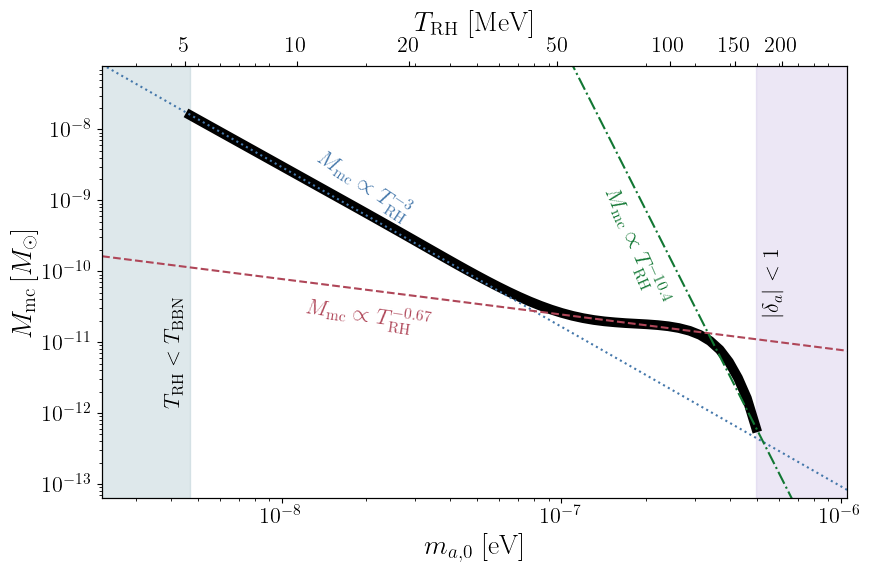

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from scipy.optimize import curve_fit
from NSC_cosmo import background

plt.rcParams.update({
    "pdf.fonttype": 42,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlesize": 18,
})

data = np.loadtxt("Data/geffcbest.txt", skiprows=0)
T_tab = data[:, 0]
gstar = interp1d(T_tab, data[:, 1], bounds_error=False, fill_value="extrapolate")

data = np.loadtxt("Data/heffcbest.txt", skiprows=0)
T_tab = data[:, 0]
gstars = interp1d(T_tab, data[:, 1], bounds_error=False, fill_value="extrapolate")

data = np.loadtxt("Data/gstarcbest.txt", skiprows=0)
T_tab = data[:, 0]
fgstars = interp1d(T_tab, data[:, 1], bounds_error=False, fill_value="extrapolate")

def _mass(T, Tl, b, ma0):
    T_arr = np.asarray(T, dtype=float)
    if b == 0:
        return np.full_like(T_arr, ma0, dtype=float)
    return np.where(T_arr <= Tl, ma0, ma0 * (Tl / T_arr) ** b)

Mp = 2.4e18
h = 0.67810
rho_c = 3.445e-47 
T_0 = 2.33e-13
omega_cdm = 0.1201075

A = 5.69 * 10**(-3)
rho_a_0 = omega_cdm * rho_c / h**2
term_1 = (A**2 / rho_a_0) ** (2/3)

T0_Mp = T_0**2 / Mp
gstarS_T0 = np.float64(gstars(T_0))
term_2 = (T0_Mp * gstarS_T0**(2/3))
T_RH_plot = np.logspace(np.log10(0.003), np.log10(0.300), 100)
theta_i = 0.8
zeta = 0.15 / T_RH_plot
ma_terms = term_1 * term_2 * (2 * np.pi**2 / 45)**(1/2) * np.mean(gstar(T_RH_plot)**(1/2) / gstars(T_RH_plot)**(2/3)) 
ma_trh_plot = ma_terms * theta_i**(4/3) * zeta**(-4/3) * 1e9

MA_MIN = ma_trh_plot[0]
MA_Max = ma_trh_plot[-1]

def fit_model_low(x, a):
    return a * (x / 150.0)**(-3.0) 

def fit_model_mid(x, a, b):
    return a * (x / 150.0)**(b) 

def fit_model_high(x, a, b):
    return a * (x / 150.0)**(b)

mask_low = (T_v >= 15.0) & (T_v <= 35.0)
x_fit_low = T_v[mask_low]
y_fit_low = Mc_v[mask_low]

p0_low = [1e-6]
bounds_low = ([1e-15], [1e-1])

popt_low, _ = curve_fit(fit_model_low, x_fit_low, y_fit_low, p0=p0_low, bounds=bounds_low, sigma=y_fit_low, absolute_sigma=False, maxfev=10000)
a_low = popt_low[0]
b_low = -3.0 

mask_mid = (T_v > 35.0) & (T_v <= 150.0)
x_fit_mid = T_v[mask_mid]
y_fit_mid = Mc_v[mask_mid]

p0_mid = [1e-6, -3.0]
bounds_mid = ([1e-15, -20.0], [1e-1, 10.0])

popt_mid, _ = curve_fit(fit_model_mid, x_fit_mid, y_fit_mid, p0=p0_mid, bounds=bounds_mid, sigma=y_fit_mid, absolute_sigma=False, maxfev=10000)
a_mid = 1.50 * 1e-11 * 0.8
b_mid = -2.0 / 3.0

mask_high = (T_v >= 150.0) 
x_fit_high = T_v[mask_high]
y_fit_high = Mc_v[mask_high]

p0_high = [1e-6, -3.0]
bounds_high = ([1e-15, -15.0], [1e-1, 10.0])

popt_high, _ = curve_fit(fit_model_high, x_fit_high, y_fit_high, p0=p0_high, bounds=bounds_high, sigma=y_fit_high, absolute_sigma=False, maxfev=10000)
b_high = popt_high[1]

T_ext = T_RH_plot * 1000.0
M_ext = ma_trh_plot

T_anchor = np.interp(M_v[-1], M_ext, T_ext)
a_high = Mc_v[-1] / (T_anchor / 150.0)**b_high

Mc_low_arr = a_low * (T_ext / 150.0)**b_low
Mc_mid_arr = a_mid * (T_ext / 150.0)**b_mid
Mc_high_arr = a_high * (T_ext / 150.0)**b_high

fig, ax1 = plt.subplots(figsize=(9, 6))

cb_colors = ['#4477AA', "#AF4658", '#DDCC77', '#117733']

ax1.plot(M_v, Mc_v, color="black", lw=7, zorder=1)

ax1.plot(M_ext, Mc_low_arr, color=cb_colors[0], ls=':', lw=1.5, zorder=2)
ax1.plot(M_ext, Mc_mid_arr, color=cb_colors[1], ls='--', lw=1.5, zorder=2)
ax1.plot(M_ext, Mc_high_arr, color=cb_colors[3], ls='-.', lw=1.5, zorder=2)

ax1.set_xlim(MA_MIN, MA_Max)
ax1.set_ylim(Mc_v.min() * 0.1, Mc_v.max() * 5.0)

def place_text(ax, x_arr, y_arr, idx, text, color, v_shift):
    idx1 = max(0, idx - 5)
    idx2 = min(len(x_arr) - 1, idx + 5)
    
    dx = np.log10(x_arr[idx2]) - np.log10(x_arr[idx1])
    dy = np.log10(y_arr[idx2]) - np.log10(y_arr[idx1])
    
    dx_lim = np.log10(ax.get_xlim()[1]) - np.log10(ax.get_xlim()[0])
    dy_lim = np.log10(ax.get_ylim()[1]) - np.log10(ax.get_ylim()[0])
    
    rot = np.degrees(np.arctan2((dy / dy_lim) * 6.0, (dx / dx_lim) * 9.0))
    ax.text(x_arr[idx], y_arr[idx] * v_shift, text, color=color, rotation=rot, ha='center', va='bottom')

idx_low = np.argmin(np.abs(T_ext - 25.0))
place_text(ax1, M_ext/2, Mc_low_arr*2.2, idx_low, r'$M_{\mathrm{mc}} \propto T_{\mathrm{RH}}^{-3}$', cb_colors[0], 1.5)

idx_mid = np.argmin(np.abs(T_ext - 75.0))
place_text(ax1, M_ext/8, Mc_mid_arr*0.4, idx_mid, fr'$M_{{\mathrm{{mc}}}} \propto T_{{\mathrm{{RH}}}}^{{{b_mid:.2f}}}$', cb_colors[1], 1.5)

idx_high = np.argmin(np.abs(T_ext - 170.0))
place_text(ax1, M_ext/2.7, Mc_high_arr*24, idx_high, fr'$M_{{\mathrm{{mc}}}} \propto T_{{\mathrm{{RH}}}}^{{{b_high:.1f}}}$', cb_colors[3], 2.0)

y_mid = 10**((np.log10(ax1.get_ylim()[1]) + np.log10(ax1.get_ylim()[0])) / 2.0)
ys = 1

m_min_data = M_v[0]
ax1.text(m_min_data * 0.95, y_mid*1e-1, r'$T_{\mathrm{RH}} < T_{\mathrm{BBN}}$', color="black", rotation=90, va='center', ha='right')
ax1.axvspan(MA_MIN, m_min_data, color='#AEC6CF', alpha=0.4, zorder=-1)

m_max_data = M_v[-1]
ax1.text(m_max_data * 1.05, y_mid*ys, r'$|\delta_a| < 1$', color="black", rotation=90, va='center', ha='left')
ax1.axvspan(m_max_data, MA_Max, color='#C3B1E1', alpha=0.3, zorder=-1)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'$m_{a,0}$ [eV]')
ax1.set_ylabel(r'$M_{\mathrm{mc}}\,[M_\odot]$')

ax2 = ax1.twiny()
ax2.set_xscale('log')
ax2.set_xlim(ax1.get_xlim())

nice_T_ticks = np.array([3, 5, 10, 20, 50, 100, 150, 200, 300])
sort_idx_ext = np.argsort(T_ext)
T_ext_s = T_ext[sort_idx_ext]
M_ext_s = M_ext[sort_idx_ext]
valid_ticks = nice_T_ticks[(nice_T_ticks >= T_ext_s[0]) & (nice_T_ticks <= T_ext_s[-1])]
tick_pos = 10**np.interp(np.log10(valid_ticks), np.log10(T_ext_s), np.log10(M_ext_s))

ax2.set_xticks(tick_pos)
ax2.set_xticklabels([f"{int(t)}" if t == int(t) else f"{t:g}" for t in valid_ticks])
ax2.set_xlabel(r'$T_{\mathrm{RH}}$ [MeV]')

plt.savefig("QCD_axion_eq_an.pdf", dpi=300)
plt.tight_layout()
plt.show()

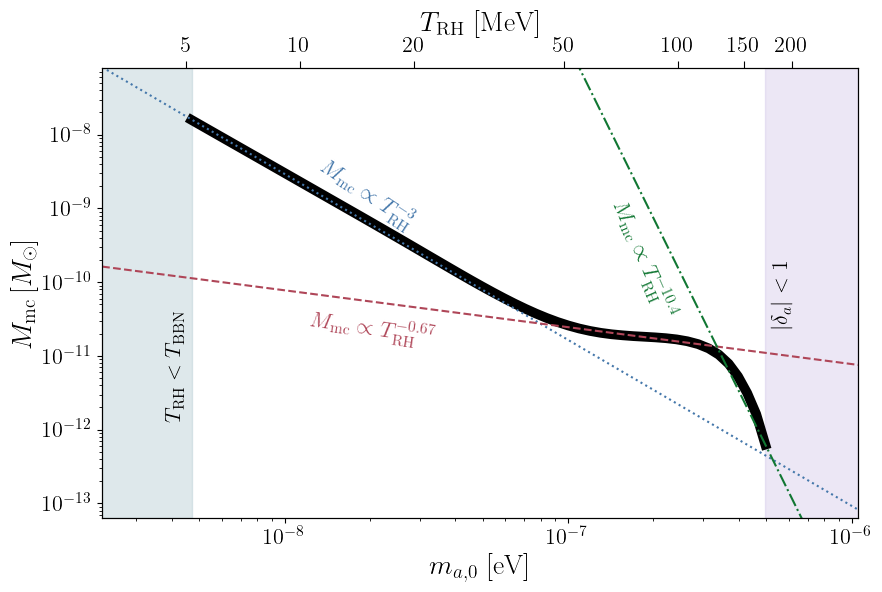

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

plt.rcParams.update({
    "pdf.fonttype": 42,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlesize": 18,
})

energy_data = np.loadtxt("Data/geffcbest.txt", skiprows=0)
temperature_table = energy_data[:, 0]
energy_degrees = interp1d(
    temperature_table,
    energy_data[:, 1],
    bounds_error=False,
    fill_value="extrapolate",
)

entropy_data = np.loadtxt("Data/heffcbest.txt", skiprows=0)
temperature_table = entropy_data[:, 0]
entropy_degrees = interp1d(
    temperature_table,
    entropy_data[:, 1],
    bounds_error=False,
    fill_value="extrapolate",
)

effective_data = np.loadtxt("Data/gstarcbest.txt", skiprows=0)
temperature_table = effective_data[:, 0]
effective_degrees = interp1d(
    temperature_table,
    effective_data[:, 1],
    bounds_error=False,
    fill_value="extrapolate",
)

planck_mass = 2.4e18
hubble_reduced = 0.67810
critical_density = 3.445e-47
today_temperature = 2.33e-13
cold_dark_matter_density = 0.1201075

normalization = 5.69e-3
today_axion_density = cold_dark_matter_density * critical_density / hubble_reduced**2
density_factor = (normalization**2 / today_axion_density) ** (2.0 / 3.0)

temperature_factor = today_temperature**2 / planck_mass
today_entropy_degrees = np.float64(entropy_degrees(today_temperature))
entropy_factor = temperature_factor * today_entropy_degrees**(2.0 / 3.0)

reheating_temperature_grid_gev = np.logspace(np.log10(0.003), np.log10(0.300), 100)
reheating_temperature_grid_mev = reheating_temperature_grid_gev * 1000.0

initial_angle = 0.8
zeta_grid = 0.15 / reheating_temperature_grid_gev

degree_factor = np.mean(
    energy_degrees(reheating_temperature_grid_gev)**0.5
    / entropy_degrees(reheating_temperature_grid_gev)**(2.0 / 3.0)
)

axion_mass_grid = (
    density_factor
    * entropy_factor
    * (2.0 * np.pi**2 / 45.0)**0.5
    * degree_factor
    * initial_angle**(4.0 / 3.0)
    * zeta_grid**(-4.0 / 3.0)
    * 1e9
)

minimum_axion_mass = axion_mass_grid[0]
maximum_axion_mass = axion_mass_grid[-1]

axion_mass_values = np.asarray(M_v, dtype=float)
minicluster_mass_values = np.asarray(Mc_v, dtype=float)
reheating_temperature_values = np.asarray(T_v, dtype=float)

valid_values = (
    np.isfinite(axion_mass_values)
    & np.isfinite(minicluster_mass_values)
    & np.isfinite(reheating_temperature_values)
    & (axion_mass_values > 0.0)
    & (minicluster_mass_values > 0.0)
    & (reheating_temperature_values > 0.0)
)

axion_mass_values = axion_mass_values[valid_values]
minicluster_mass_values = minicluster_mass_values[valid_values]
reheating_temperature_values = reheating_temperature_values[valid_values]

if np.nanmax(reheating_temperature_values) < 1.0:
    reheating_temperature_values = reheating_temperature_values * 1000.0

sorting = np.argsort(axion_mass_values)
axion_mass_values = axion_mass_values[sorting]
minicluster_mass_values = minicluster_mass_values[sorting]
reheating_temperature_values = reheating_temperature_values[sorting]

def low_fit_model(temperature, amplitude):
    return amplitude * (temperature / 150.0)**(-3.0)

def middle_fit_model(temperature, amplitude, exponent):
    return amplitude * (temperature / 150.0)**exponent

def high_fit_model(temperature, amplitude, exponent):
    return amplitude * (temperature / 150.0)**exponent

low_fit_mask = (
    (reheating_temperature_values >= 15.0)
    & (reheating_temperature_values <= 35.0)
)

low_fit_temperature = reheating_temperature_values[low_fit_mask]
low_fit_mass = minicluster_mass_values[low_fit_mask]

low_fit_parameters, _ = curve_fit(
    low_fit_model,
    low_fit_temperature,
    low_fit_mass,
    p0=[1e-6],
    bounds=([1e-15], [1e-1]),
    sigma=low_fit_mass,
    absolute_sigma=False,
    maxfev=10000,
)

low_amplitude = low_fit_parameters[0]
low_exponent = -3.0

middle_fit_mask = (
    (reheating_temperature_values > 35.0)
    & (reheating_temperature_values <= 150.0)
)

middle_fit_temperature = reheating_temperature_values[middle_fit_mask]
middle_fit_mass = minicluster_mass_values[middle_fit_mask]

middle_fit_parameters, _ = curve_fit(
    middle_fit_model,
    middle_fit_temperature,
    middle_fit_mass,
    p0=[1e-6, -3.0],
    bounds=([1e-15, -20.0], [1e-1, 10.0]),
    sigma=middle_fit_mass,
    absolute_sigma=False,
    maxfev=10000,
)

middle_amplitude = 1.50e-11 * 0.8
middle_exponent = -2.0 / 3.0

high_fit_mask = reheating_temperature_values >= 150.0

high_fit_temperature = reheating_temperature_values[high_fit_mask]
high_fit_mass = minicluster_mass_values[high_fit_mask]

high_fit_parameters, _ = curve_fit(
    high_fit_model,
    high_fit_temperature,
    high_fit_mass,
    p0=[1e-6, -3.0],
    bounds=([1e-15, -15.0], [1e-1, 10.0]),
    sigma=high_fit_mass,
    absolute_sigma=False,
    maxfev=10000,
)

high_exponent = high_fit_parameters[1]

anchor_temperature = np.interp(
    axion_mass_values[-1],
    axion_mass_grid,
    reheating_temperature_grid_mev,
)

high_amplitude = (
    minicluster_mass_values[-1]
    / (anchor_temperature / 150.0)**high_exponent
)

low_fit_curve = low_amplitude * (reheating_temperature_grid_mev / 150.0)**low_exponent
middle_fit_curve = middle_amplitude * (reheating_temperature_grid_mev / 150.0)**middle_exponent
high_fit_curve = high_amplitude * (reheating_temperature_grid_mev / 150.0)**high_exponent

figure, main_axis = plt.subplots(figsize=(9, 6))

plot_colors = ["#4477AA", "#AF4658", "#DDCC77", "#117733"]

main_axis.plot(
    axion_mass_values,
    minicluster_mass_values,
    color="black",
    lw=7,
    zorder=1,
)

main_axis.plot(
    axion_mass_grid,
    low_fit_curve,
    color=plot_colors[0],
    ls=":",
    lw=1.5,
    zorder=2,
)

main_axis.plot(
    axion_mass_grid,
    middle_fit_curve,
    color=plot_colors[1],
    ls="--",
    lw=1.5,
    zorder=2,
)

main_axis.plot(
    axion_mass_grid,
    high_fit_curve,
    color=plot_colors[3],
    ls="-.",
    lw=1.5,
    zorder=2,
)

main_axis.set_xlim(minimum_axion_mass, maximum_axion_mass)
main_axis.set_ylim(
    minicluster_mass_values.min() * 0.1,
    minicluster_mass_values.max() * 5.0,
)

main_axis.set_xscale("log")
main_axis.set_yscale("log")

def add_power_law_label(axis, x_values, y_values, index, label, color, vertical_shift):
    lower_index = max(0, index - 5)
    upper_index = min(len(x_values) - 1, index + 5)

    log_x_width = np.log10(x_values[upper_index]) - np.log10(x_values[lower_index])
    log_y_width = np.log10(y_values[upper_index]) - np.log10(y_values[lower_index])

    axis_log_x_width = np.log10(axis.get_xlim()[1]) - np.log10(axis.get_xlim()[0])
    axis_log_y_width = np.log10(axis.get_ylim()[1]) - np.log10(axis.get_ylim()[0])

    rotation_angle = np.degrees(
        np.arctan2(
            (log_y_width / axis_log_y_width) * 6.0,
            (log_x_width / axis_log_x_width) * 9.0,
        )
    )

    axis.text(
        x_values[index],
        y_values[index] * vertical_shift,
        label,
        color=color,
        rotation=rotation_angle,
        ha="center",
        va="bottom",
        clip_on=True,
    )

low_label_index = np.argmin(np.abs(reheating_temperature_grid_mev - 25.0))

add_power_law_label(
    main_axis,
    axion_mass_grid / 2.0,
    low_fit_curve * 2.2,
    low_label_index,
    r"$M_{\mathrm{mc}} \propto T_{\mathrm{RH}}^{-3}$",
    plot_colors[0],
    1.5,
)

middle_label_index = np.argmin(np.abs(reheating_temperature_grid_mev - 75.0))

add_power_law_label(
    main_axis,
    axion_mass_grid / 8.0,
    middle_fit_curve * 0.4,
    middle_label_index,
    fr"$M_{{\mathrm{{mc}}}} \propto T_{{\mathrm{{RH}}}}^{{{middle_exponent:.2f}}}$",
    plot_colors[1],
    1.5,
)

high_label_index = np.argmin(np.abs(reheating_temperature_grid_mev - 170.0))

add_power_law_label(
    main_axis,
    axion_mass_grid / 2.7,
    high_fit_curve * 24.0,
    high_label_index,
    fr"$M_{{\mathrm{{mc}}}} \propto T_{{\mathrm{{RH}}}}^{{{high_exponent:.1f}}}$",
    plot_colors[3],
    2.0,
)

vertical_center = 10.0**(
    0.5 * (
        np.log10(main_axis.get_ylim()[0])
        + np.log10(main_axis.get_ylim()[1])
    )
)

minimum_data_mass = axion_mass_values[0]
maximum_data_mass = axion_mass_values[-1]

main_axis.axvspan(
    minimum_axion_mass,
    minimum_data_mass,
    color="#AEC6CF",
    alpha=0.4,
    zorder=-1,
)

main_axis.text(
    minimum_data_mass * 0.95,
    vertical_center * 1e-1,
    r"$T_{\mathrm{RH}} < T_{\mathrm{BBN}}$",
    color="black",
    rotation=90,
    va="center",
    ha="right",
)

main_axis.axvspan(
    maximum_data_mass,
    maximum_axion_mass,
    color="#C3B1E1",
    alpha=0.3,
    zorder=-1,
)

main_axis.text(
    maximum_data_mass * 1.05,
    vertical_center,
    r"$|\delta_a| < 1$",
    color="black",
    rotation=90,
    va="center",
    ha="left",
)

main_axis.set_xlabel(r"$m_{a,0}$ [eV]")
main_axis.set_ylabel(r"$M_{\mathrm{mc}}\,[M_\odot]$")

top_axis = main_axis.twiny()
top_axis.set_xscale("log")
top_axis.set_xlim(main_axis.get_xlim())

axis_sorting = np.argsort(reheating_temperature_grid_mev)

temperature_axis_grid = np.asarray(
    reheating_temperature_grid_mev[axis_sorting],
    dtype=float,
)

axion_mass_axis_grid = np.asarray(
    axion_mass_grid[axis_sorting],
    dtype=float,
)

axis_valid_values = (
    np.isfinite(temperature_axis_grid)
    & np.isfinite(axion_mass_axis_grid)
    & (temperature_axis_grid > 0.0)
    & (axion_mass_axis_grid > 0.0)
)

temperature_axis_grid = temperature_axis_grid[axis_valid_values]
axion_mass_axis_grid = axion_mass_axis_grid[axis_valid_values]

temperature_ticks = np.array([5, 10, 20, 50, 100, 150, 200], dtype=float)

temperature_ticks = temperature_ticks[
    (temperature_ticks >= temperature_axis_grid.min())
    & (temperature_ticks <= temperature_axis_grid.max())
]

tick_positions = 10.0**np.interp(
    np.log10(temperature_ticks),
    np.log10(temperature_axis_grid),
    np.log10(axion_mass_axis_grid),
)

top_axis.xaxis.set_major_locator(ticker.FixedLocator(tick_positions))
top_axis.xaxis.set_major_formatter(
    ticker.FixedFormatter([rf"${int(tick)}$" for tick in temperature_ticks])
)

top_axis.xaxis.set_minor_locator(ticker.NullLocator())
top_axis.xaxis.set_minor_formatter(ticker.NullFormatter())

top_axis.tick_params(
    axis="x",
    which="major",
    direction="out",
    length=5,
    pad=4,
)

top_axis.tick_params(
    axis="x",
    which="minor",
    length=0,
)

top_axis.set_xlabel(r"$T_{\mathrm{RH}}$ [MeV]")

figure.subplots_adjust(
    left=0.13,
    right=0.97,
    bottom=0.13,
    top=0.88,
)

figure.savefig("QCD_axion_eq_an.pdf", dpi=300)
plt.show()